Proyecto 2: Introducción a la Inteligencia Artificial

Integrantes: Vicente Arechavala, Johan Riveros

Profesor: Gabriel Cabas

### Librerias a utilizar

In [1]:
#Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torch.nn import CrossEntropyLoss

Carga de modelo de preentreno

In [3]:
#Se usará resnet18 (por ahora por limitaciones de cpu)
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

Transformaciones definidas

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

Carga del dataset

In [5]:
import os
import platform

NUM_WORKERS = 0 if platform.system() == "Windows" else min(4, os.cpu_count() or 0)
print("NUM_WORKERS:", NUM_WORKERS)

train_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/train", transform=train_transform)
val_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/val", transform=eval_transform)
test_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/test", transform=eval_transform)

train_loader = DataLoader(train_folder, batch_size=64, shuffle=True,
                           num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_folder, batch_size=64, shuffle=False,
                         num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(test_folder, batch_size=64, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)

CLASSES = train_folder.classes
NUM_CLASSES = len(CLASSES)

print("Clases:", train_folder.class_to_idx)
print(f"Train: {len(train_folder)} | Val: {len(val_folder)} | Test: {len(test_folder)}")


NUM_WORKERS: 0
Clases: {'paper': 0, 'rock': 1, 'scissors': 2}
Train: 1020 | Val: 804 | Test: 540


Distribución de las clases del dataset

Imágenes por clase (train):
paper       362
rock        329
scissors    329
Name: count, dtype: int64


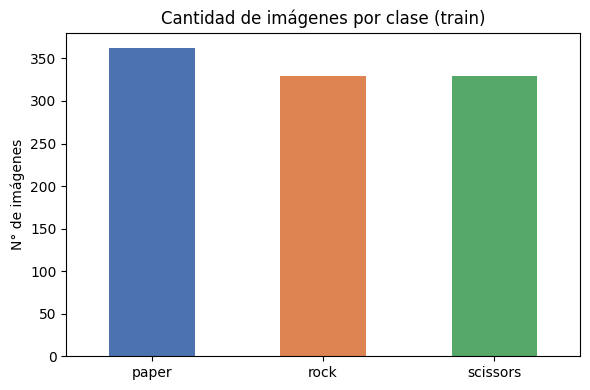


Desbalance (max/min): 1.10x


In [6]:
# Distribución de clases en el set de entrenamiento
train_labels = [label for _, label in train_folder.samples]
class_counts = pd.Series(train_labels).value_counts().sort_index()
class_counts.index = [CLASSES[i] for i in class_counts.index]

print("Imágenes por clase (train):")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Cantidad de imágenes por clase (train)")
plt.ylabel("N° de imágenes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nDesbalance (max/min): {class_counts.max() / class_counts.min():.2f}x")


Imagenes aleatorias del dataset

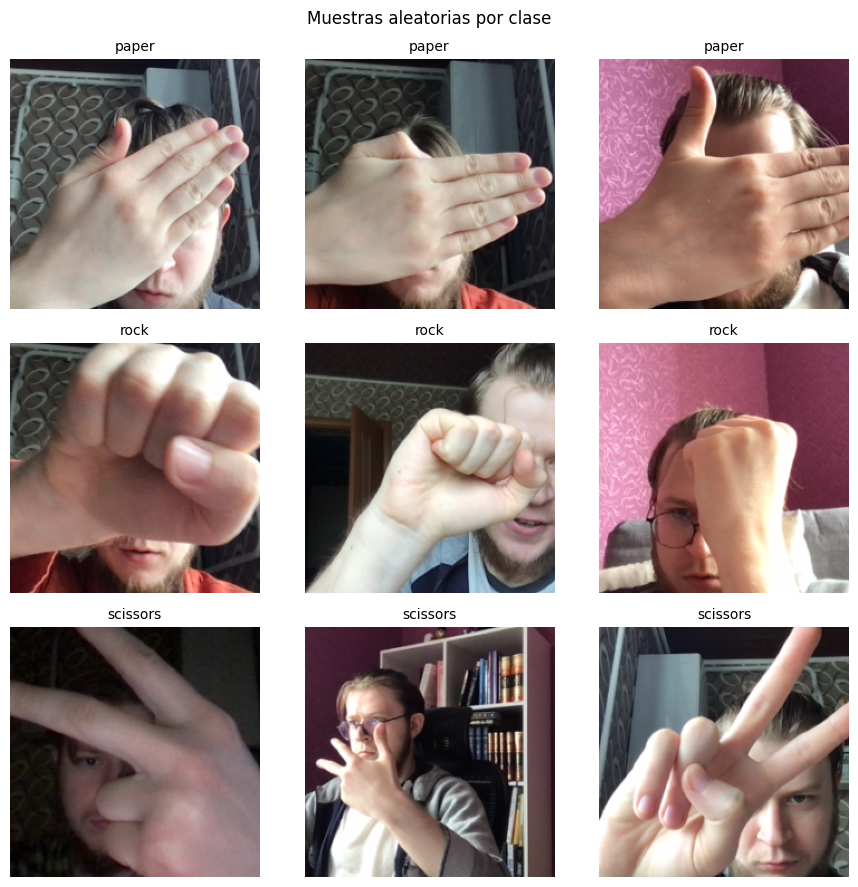

In [7]:
# Muestra visual: 3 imágenes por clase (antes de normalizar)
raw_view = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/train", transform=transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224)
]))

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 3 * len(CLASSES)))
rng = np.random.default_rng(42)

for row, class_name in enumerate(CLASSES):
    class_idx = raw_view.class_to_idx[class_name]
    sample_indices = [i for i, (_, lbl) in enumerate(raw_view.samples) if lbl == class_idx]
    chosen = rng.choice(sample_indices, size=3, replace=False)
    for col, idx in enumerate(chosen):
        img, _ = raw_view[idx]
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(class_name, fontsize=10)
        ax.axis("off")

plt.suptitle("Muestras aleatorias por clase")
plt.tight_layout()
plt.show()


Verificación de tamaño de imagenes

In [8]:
# Verificación de tamaños/formatos originales de imagen (antes del resize)
from PIL import Image

sample_paths = [raw_view.samples[i][0] for i in rng.choice(len(raw_view), size=min(200, len(raw_view)), replace=False)]
sizes = [Image.open(p).size for p in sample_paths]
widths, heights = zip(*sizes)

print(f"Ancho: min={min(widths)}, max={max(widths)}, promedio={np.mean(widths):.0f}")
print(f"Alto:  min={min(heights)}, max={max(heights)}, promedio={np.mean(heights):.0f}")

Ancho: min=300, max=300, promedio=300
Alto:  min=300, max=300, promedio=300


Todas las imágenes originales son de 300 × 300 píxeles.

### Modelo

Congelar backbone

In [9]:
for param in model.parameters():
    param.requires_grad = False

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
model.to(device)

Device: cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [11]:
# Crear una nueva cabeza entrenable
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Parámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.2f}%)")

Parámetros entrenables: 132,611 / 11,309,123 (1.17%)


In [17]:
criterion = CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4  # regularización L2
)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 5
PATIENCE = 3

In [18]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

In [19]:
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} acc={train_acc:.3f} "
          f"| val_loss={val_loss:.4f} acc={val_acc:.3f}")

    # --- early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping en epoch {epoch+1}")
            break

model.load_state_dict(best_state)

Epoch 1/5 | train_loss=1.0352 acc=0.482 | val_loss=1.0013 acc=0.527
Epoch 2/5 | train_loss=0.8902 acc=0.597 | val_loss=0.9026 acc=0.642
Epoch 3/5 | train_loss=0.7977 acc=0.669 | val_loss=0.8432 acc=0.675
Epoch 4/5 | train_loss=0.7198 acc=0.725 | val_loss=0.7925 acc=0.703
Epoch 5/5 | train_loss=0.6432 acc=0.783 | val_loss=0.7493 acc=0.733


<All keys matched successfully>

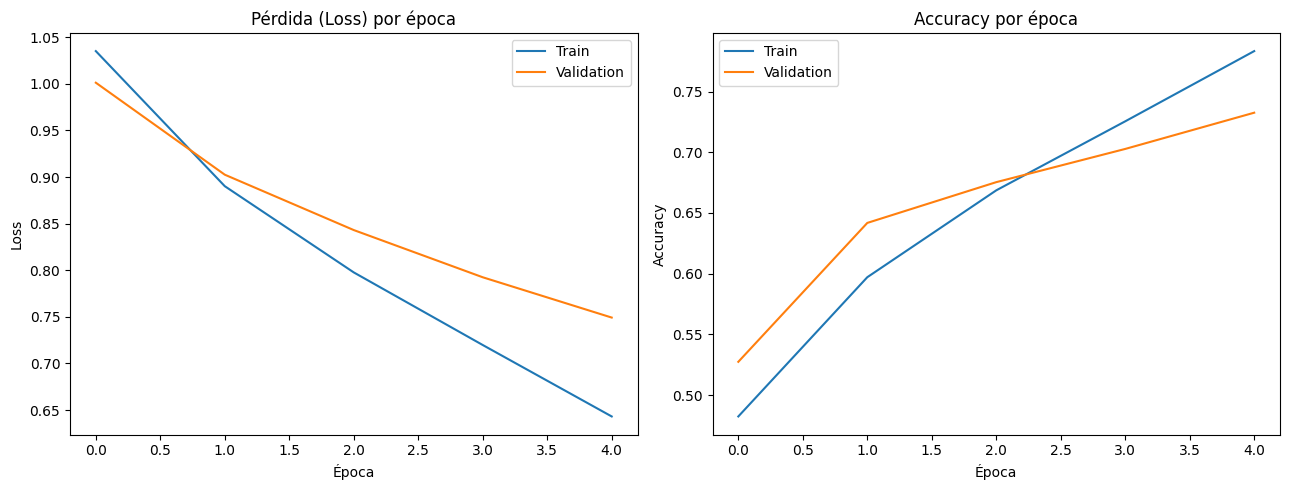

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Pérdida (Loss) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


Testeo

In [21]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_acc:.4f}")

print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=3, zero_division=0))


Accuracy en test: 0.5630

Reporte de clasificación:
              precision    recall  f1-score   support

       paper      0.446     0.517     0.479       176
        rock      0.714     0.426     0.533       188
    scissors      0.594     0.756     0.665       176

    accuracy                          0.563       540
   macro avg      0.585     0.566     0.559       540
weighted avg      0.588     0.563     0.559       540



Matriz de confusión

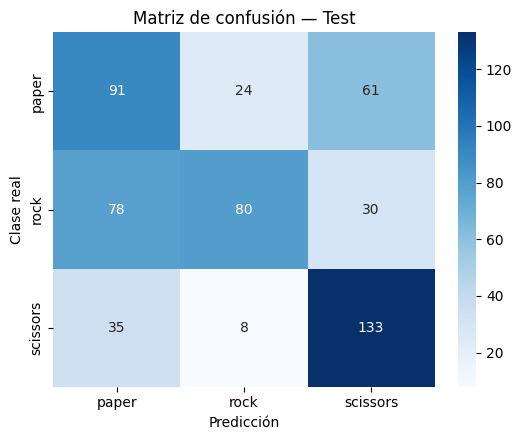

In [22]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Matriz de confusión — Test")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()


Visualización de aciertos

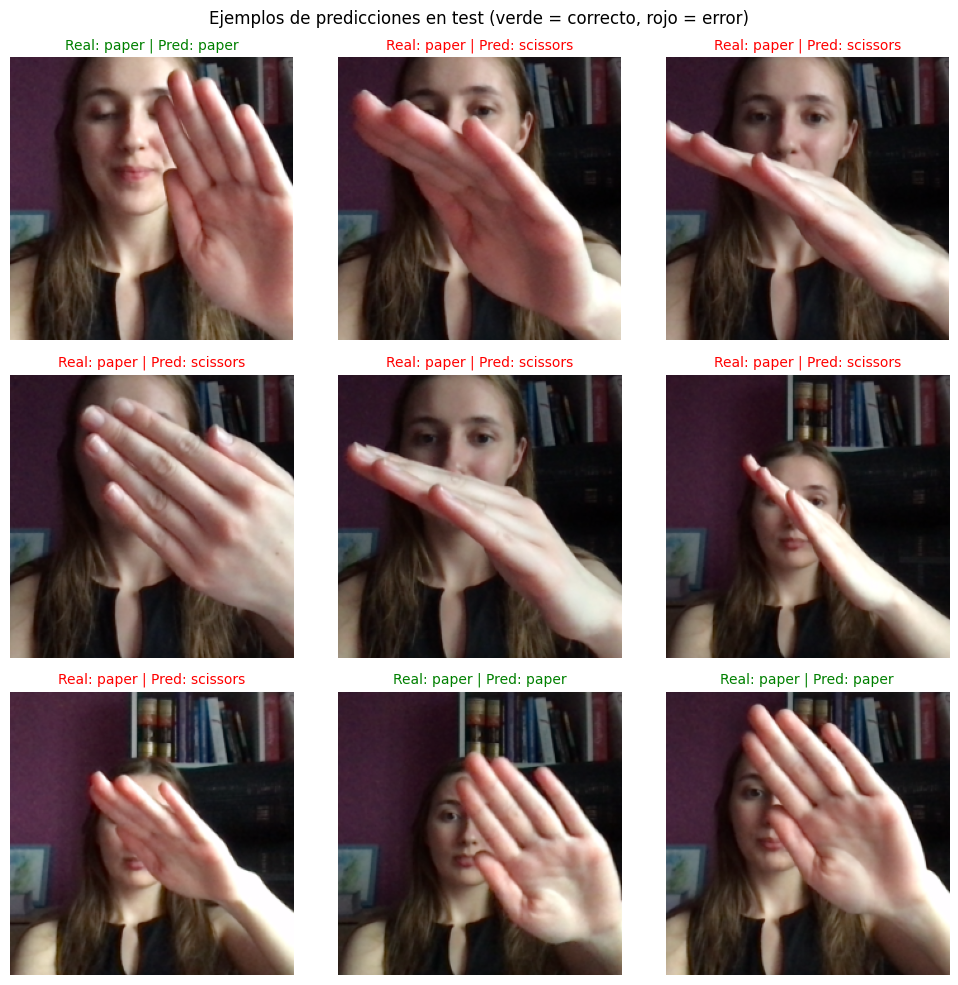

In [23]:
# Visualización de predicciones individuales (aciertos y errores) sobre imágenes de test
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()
images, labels = next(iter(test_loader))
images_dev = images.to(device)
with torch.no_grad():
    preds = model(images_dev).argmax(1).cpu()

n_show = min(9, len(images))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, img, true_label, pred_label in zip(axes.flat, images[:n_show], labels[:n_show], preds[:n_show]):
    ax.imshow(denormalize(img))
    true_name, pred_name = CLASSES[true_label], CLASSES[pred_label]
    correct = true_label == pred_label
    ax.set_title(f"Real: {true_name} | Pred: {pred_name}",
                 color="green" if correct else "red", fontsize=10)
    ax.axis("off")
for ax in axes.flat[n_show:]:
    ax.axis("off")

plt.suptitle("Ejemplos de predicciones en test (verde = correcto, rojo = error)")
plt.tight_layout()
plt.show()
